# 01 · Confidence vs activity

Do the co-folding confidence metrics carry any signal about experimental activity, and how do they relate to the cached Boltz-2 screening score? These are structural-confidence signals, not the affinity score itself (that comes from Pass-2).

> Preliminary. These use the ~20k compounds co-folded so far (a partial, roughly CID-ordered — hence roughly random — sample of the 49,985-compound library). Absolute numbers will shift as folding completes, and none of this includes fine-tuning yet, so nothing here speaks to the paper head-FT claim. What it does show: whether the co-folding is healthy, and whether the structural-confidence signals carry any activity information.

In [1]:
import os, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_columns", 40)
ROOT = Path("/global/scratch/users/sergiomar10/boltzaff")
QC = pd.read_csv(ROOT / "results/runs/588689/qc.csv")
# all text black, normal weight (no bold)
BLK="#000000"; GRID="#dedede"
PALETTE=["#2a78d6","#eb6834","#1baf7a","#eda100","#e87ba4","#4a3aa7","#e34948","#008300"]
ACTIVE="#1baf7a"; INACTIVE="#9aa0a6"; BLUE="#2a78d6"
mpl.rcParams.update({
  "figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":GRID,"grid.linewidth":0.6,"axes.axisbelow":True,
  "axes.spines.top":False,"axes.spines.right":False,"figure.dpi":100})
METRICS=["confidence","complex_plddt","ptm","iptm","ligand_iptm","complex_pde"]
print(f"folded compounds: {len(QC)}   actives: {int(QC.Active.sum())} ({QC.Active.mean()*100:.2f}%)")


folded compounds: 21061   actives: 238 (1.13%)


## Metric distributions: actives vs inactives

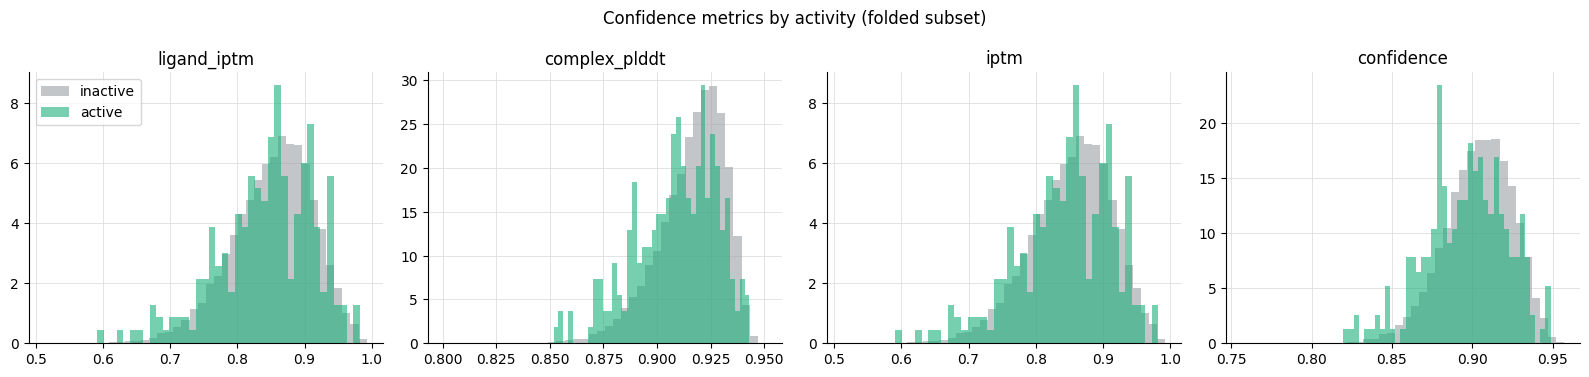

In [2]:
show=["ligand_iptm","complex_plddt","iptm","confidence"]
fig,axes=plt.subplots(1,4,figsize=(16,3.8))
for ax,m in zip(axes,show):
    ax.hist(QC[QC.Active==0][m].dropna(),bins=40,density=True,alpha=.6,color=INACTIVE,label="inactive")
    ax.hist(QC[QC.Active==1][m].dropna(),bins=40,density=True,alpha=.6,color=ACTIVE,label="active")
    ax.set_title(m)
axes[0].legend()
fig.suptitle("Confidence metrics by activity (folded subset)")
plt.tight_layout(); plt.show()

## Correlation among score and confidence metrics (Spearman)

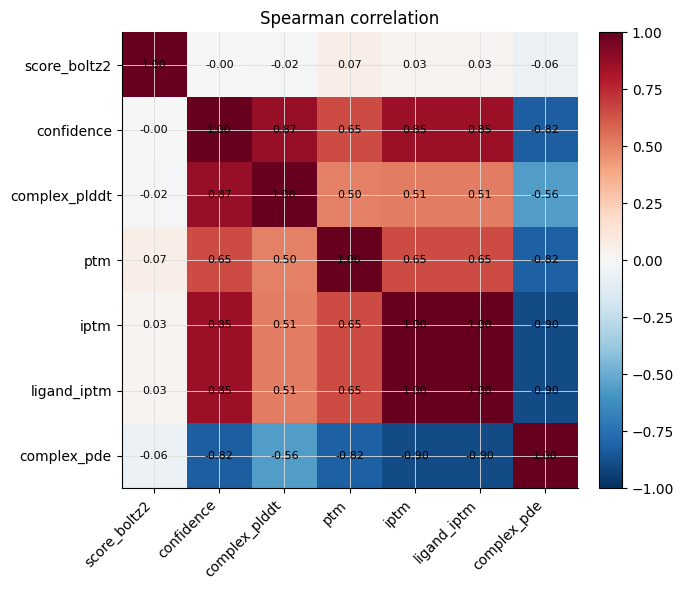

In [3]:
cols=["score_boltz2"]+METRICS
corr=QC[cols].corr(method="spearman")
fig,ax=plt.subplots(figsize=(7,6))
im=ax.imshow(corr.values,cmap="RdBu_r",vmin=-1,vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols,rotation=45,ha="right")
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j,i,f"{corr.values[i,j]:.2f}",ha="center",va="center",fontsize=8,color=BLK)
plt.colorbar(im,fraction=0.046,pad=0.04); ax.set_title("Spearman correlation")
plt.tight_layout(); plt.show()

## Median metric by activity

In [4]:
QC.groupby("Active")[["score_boltz2"]+METRICS].median().T.rename(columns={0:"inactive",1:"active"})

Active,inactive,active
score_boltz2,0.220734,0.517769
confidence,0.905179,0.897611
complex_plddt,0.919120,0.910479
ptm,0.949142,0.947211
iptm,0.858826,0.849674
ligand_iptm,0.858826,0.849674
complex_pde,0.465372,0.468537
